In [29]:
import math
import numpy as np
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, rand, regexp_extract

In [30]:
# 1) START SPARK SESSION

spark = (
    SparkSession.builder
    .appName("DiabetesReadmissionLocal")
    .master("local[*]")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")


In [31]:
# 2) FILE PATHS

FULL_DATA_PATH = "diabetic_data.csv"
SMALL_DATA_PATH = "diabetic_data_small"

In [32]:
# 3) LOAD FULL DATASET

df_full = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(FULL_DATA_PATH)
)

print("Full dataset row count:", df_full.count())
print("Full dataset columns:", len(df_full.columns))
df_full.printSchema()

Full dataset row count: 101766
Full dataset columns: 50
root
 |-- encounter_id: integer (nullable = true)
 |-- patient_nbr: integer (nullable = true)
 |-- race: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: string (nullable = true)
 |-- weight: string (nullable = true)
 |-- admission_type_id: integer (nullable = true)
 |-- discharge_disposition_id: integer (nullable = true)
 |-- admission_source_id: integer (nullable = true)
 |-- time_in_hospital: integer (nullable = true)
 |-- payer_code: string (nullable = true)
 |-- medical_specialty: string (nullable = true)
 |-- num_lab_procedures: integer (nullable = true)
 |-- num_procedures: integer (nullable = true)
 |-- num_medications: integer (nullable = true)
 |-- number_outpatient: integer (nullable = true)
 |-- number_emergency: integer (nullable = true)
 |-- number_inpatient: integer (nullable = true)
 |-- diag_1: string (nullable = true)
 |-- diag_2: string (nullable = true)
 |-- diag_3: string (nullable = tr

In [ ]:
# 4) CREATE A SMALL LOCAL DATASET FROM THE FULL DATASET

# Fraction 0.10 means ~10% of the full data
df_small = df_full.sample(withReplacement=False, fraction=0.10, seed=42)

print("Small dataset row count:", df_small.count())

# Save the sampled dataset locally
(
    df_small.write
    .mode("overwrite")
    .option("header", True)
    .csv(SMALL_DATA_PATH)
)

print(f"Small dataset saved to folder: {SMALL_DATA_PATH}")

Small dataset row count: 10179
Small dataset saved to folder: diabetic_data_small


In [34]:
# 5) RELOAD SMALL DATASET

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(SMALL_DATA_PATH)
)

print("Reloaded small dataset row count:", df.count())

Reloaded small dataset row count: 10179


In [ ]:
# 5.1) CREATE DIAGNOSIS GROUP FEATURE FROM diag_1

# Keep diag_1 as a selected column first, then convert it into a grouped feature.
# Extract the numeric part from diag_1 and map it into broad clinical categories.

df = df.withColumn(
    "diag_1_str",
    col("diag_1").cast("string")
)

df = df.withColumn(
    "diag_1_num_str",
    regexp_extract(col("diag_1_str"), r"^([0-9]+)", 1)
)

df = df.withColumn(
    "diag_1_num",
    when(col("diag_1_num_str") != "", col("diag_1_num_str").cast("int"))
)

df = df.withColumn(
    "diag_1_group",
    when(col("diag_1_str").startswith("250"), 1.0)  # diabetes
    .when(col("diag_1_num").between(390, 459), 2.0)  # circulatory
    .when(col("diag_1_num") == 785, 2.0)  # circulatory symptoms
    .when(col("diag_1_num").between(460, 519), 3.0)  # respiratory
    .when(col("diag_1_num") == 786, 3.0)  # respiratory symptoms
    .when(col("diag_1_num").between(520, 579), 4.0)  # digestive
    .when(col("diag_1_num") == 787, 4.0)  # digestive symptoms
    .when(col("diag_1_num").between(800, 999), 5.0)  # injury / poisoning
    .when(col("diag_1_num").between(710, 739), 6.0)  # musculoskeletal
    .when(col("diag_1_num") == 780, 7.0)  # general symptoms
    .when(col("diag_1_num").between(140, 239), 8.0)  # neoplasms
    .otherwise(0.0)  # other / unknown
)

df.select("diag_1_group").groupBy("diag_1_group").count().show()

+------------+-----+
|diag_1_group|count|
+------------+-----+
|         8.0|  352|
|         0.0| 2146|
|         7.0|  202|
|         1.0|  863|
|         4.0|  974|
|         3.0| 1389|
|         2.0| 3052|
|         6.0|  503|
|         5.0|  698|
+------------+-----+



In [ ]:
# 6) SELECT FEATURES FOR STARTER MODEL

selected_cols = [
    # Core utilization
    "time_in_hospital",
    "num_medications",
    "number_inpatient",
    "number_emergency",
    "number_outpatient",

    # Additional numeric severity features
    "num_lab_procedures",
    "number_diagnoses",

    # Clinical
    "A1Cresult",
    "max_glu_serum",
    "diag_1_group",

    # Demographics
    "age",
    "gender",

    # Admission context
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",

    # Diabetes treatment
    "diabetesMed",
    "change",
    "insulin",

    # Target
    "readmitted"
]

df = df.select(*selected_cols)

In [37]:
# 7) CREATE BINARY LABEL
# <30 = 1
# NO and >30 = 0

df = df.withColumn(
    "label",
    when(col("readmitted") == "<30", 1.0).otherwise(0.0)
)

In [38]:
# 8) CLEAN MISSING VALUES

# Replace "?" with null
df = df.replace("?", None)

# Fill categorical missing values
df = df.fillna({
    "A1Cresult": "None",
    "max_glu_serum": "None",
    "age": "[50-60)",
    "gender": "Unknown",
    "diabetesMed": "No",
    "change": "No",
    "insulin": "No"
})

# Drop rows missing important numeric columns
numeric_required = [
    "time_in_hospital",
    "num_medications",
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
    "num_lab_procedures",
    "number_diagnoses",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

df = df.dropna(subset=numeric_required)

print("Row count after cleaning:", df.count())

Row count after cleaning: 10179


In [39]:
# 9) MANUAL ENCODING OF CATEGORICAL FEATURES

# ---------- age ----------
df = df.withColumn(
    "age_num",
    when(col("age") == "[0-10)", 0.0)
    .when(col("age") == "[10-20)", 1.0)
    .when(col("age") == "[20-30)", 2.0)
    .when(col("age") == "[30-40)", 3.0)
    .when(col("age") == "[40-50)", 4.0)
    .when(col("age") == "[50-60)", 5.0)
    .when(col("age") == "[60-70)", 6.0)
    .when(col("age") == "[70-80)", 7.0)
    .when(col("age") == "[80-90)", 8.0)
    .when(col("age") == "[90-100)", 9.0)
    .otherwise(5.0)
)

# ---------- gender ----------
df = df.withColumn(
    "gender_num",
    when(col("gender") == "Male", 1.0)
    .when(col("gender") == "Female", 0.0)
    .otherwise(0.5)
)

# ---------- A1Cresult ----------
df = df.withColumn(
    "A1Cresult_num",
    when(col("A1Cresult") == "None", 0.0)
    .when(col("A1Cresult") == "Norm", 1.0)
    .when(col("A1Cresult") == ">7", 2.0)
    .when(col("A1Cresult") == ">8", 3.0)
    .otherwise(0.0)
)

# ---------- max_glu_serum ----------
df = df.withColumn(
    "max_glu_serum_num",
    when(col("max_glu_serum") == "None", 0.0)
    .when(col("max_glu_serum") == "Norm", 1.0)
    .when(col("max_glu_serum") == ">200", 2.0)
    .when(col("max_glu_serum") == ">300", 3.0)
    .otherwise(0.0)
)

# ---------- diabetesMed ----------
df = df.withColumn(
    "diabetesMed_num",
    when(col("diabetesMed") == "Yes", 1.0)
    .otherwise(0.0)
)

# ---------- change ----------
df = df.withColumn(
    "change_num",
    when(col("change") == "Ch", 1.0)
    .otherwise(0.0)
)

# ---------- insulin ----------
df = df.withColumn(
    "insulin_num",
    when(col("insulin") == "No", 0.0)
    .when(col("insulin") == "Steady", 1.0)
    .when(col("insulin") == "Up", 2.0)
    .when(col("insulin") == "Down", 3.0)
    .otherwise(0.0)
)

In [40]:
# 10) KEEP FINAL MODEL COLUMNS

model_cols = [
    "time_in_hospital",
    "num_medications",
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
    "num_lab_procedures",
    "number_diagnoses",
    "A1Cresult_num",
    "max_glu_serum_num",
    "diag_1_group",
    "age_num",
    "gender_num",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "diabetesMed_num",
    "change_num",
    "insulin_num",
    "label"
]

df_model = df.select(*model_cols)

print("Final modeling row count:", df_model.count())
df_model.show(5, truncate=False)

Final modeling row count: 10179
+----------------+---------------+----------------+----------------+-----------------+------------------+----------------+-------------+-----------------+------------+-------+----------+-----------------+------------------------+-------------------+---------------+----------+-----------+-----+
|time_in_hospital|num_medications|number_inpatient|number_emergency|number_outpatient|num_lab_procedures|number_diagnoses|A1Cresult_num|max_glu_serum_num|diag_1_group|age_num|gender_num|admission_type_id|discharge_disposition_id|admission_source_id|diabetesMed_num|change_num|insulin_num|label|
+----------------+---------------+----------------+----------------+-----------------+------------------+----------------+-------------+-----------------+------------+-------+----------+-----------------+------------------------+-------------------+---------------+----------+-----------+-----+
|3               |13             |0               |0               |0              

In [41]:
# 11) TRAIN / TEST SPLIT

train_df, test_df = df_model.randomSplit([0.8, 0.2], seed=42)

print("Train rows:", train_df.count())
print("Test rows:", test_df.count())

Train rows: 8231
Test rows: 1948


In [42]:
# 12) CONVERT DATAFRAME TO RDD OF (x, y)

feature_names = model_cols[:-1]
num_features = len(feature_names)

def row_to_xy(row):
    x = np.array([float(row[c]) for c in feature_names], dtype=float)
    y = float(row["label"])
    return (x, y)

train_rdd = train_df.rdd.map(row_to_xy).cache()
test_rdd = test_df.rdd.map(row_to_xy).cache()

In [43]:
# 13) STANDARDIZE FEATURES USING TRAINING DATA ONLY

def seq_stats(acc, xy):
    count, sum_x, sum_sq = acc
    x, _ = xy
    return (count + 1, sum_x + x, sum_sq + x * x)

def comb_stats(a, b):
    return (a[0] + b[0], a[1] + b[1], a[2] + b[2])

zero = (0, np.zeros(num_features), np.zeros(num_features))
count, sum_x, sum_sq = train_rdd.aggregate(zero, seq_stats, comb_stats)

means = sum_x / count
variances = (sum_sq / count) - (means ** 2)
stds = np.sqrt(np.maximum(variances, 1e-12))
stds = np.where(stds == 0, 1.0, stds)

def standardize_xy(xy):
    x, y = xy
    x_scaled = (x - means) / stds
    return (x_scaled, y)

train_rdd = train_rdd.map(standardize_xy).cache()
test_rdd = test_rdd.map(standardize_xy).cache()

In [44]:
# 13.1) ADD INTERACTION FEATURES

def add_interactions(xy):
    x, y = xy

    # Stronger interaction set
    interaction1 = x[0] * x[1]   # time_in_hospital * num_medications
    interaction2 = x[2] * x[3]   # inpatient * emergency
    interaction3 = x[4] * x[5]   # outpatient * lab procedures
    interaction4 = x[6] * x[7]   # diagnoses * A1C
    interaction5 = x[8] * x[9]   # glucose * age

    x_new = np.append(x, [
        interaction1,
        interaction2,
        interaction3,
        interaction4,
        interaction5
    ])

    return (x_new, y)

train_rdd = train_rdd.map(add_interactions).cache()
test_rdd = test_rdd.map(add_interactions).cache()

# Update feature count
num_features = num_features + 5

In this step, I introduced interaction features to enhance the model’s ability to capture relationships between variables that are not purely linear.

The original logistic regression model is inherently linear, meaning it assumes each feature independently contributes to the prediction. However, in real-world clinical data, patient outcomes such as hospital readmission are often influenced by combinations of factors rather than individual variables alone.

To address this, I created new features by multiplying pairs of existing variables:
- time_in_hospital × num_medications → captures treatment intensity during longer stays
- number_inpatient × number_emergency → reflects overall healthcare utilization severity
- number_outpatient × num_lab_procedures → represents outpatient monitoring complexity
- number_diagnoses × A1Cresult → combines comorbidity burden with diabetes control
- max_glu_serum × age → links glucose severity with patient age risk

These interaction terms allow the model to account for nonlinear relationships indirectly, without changing the underlying algorithm.

After creating these features:
- They are appended to the original feature vector
- The transformation is applied consistently to both training and testing data
- The total number of features is updated accordingly

This step was added to improve the model’s ability to distinguish between readmitted and non-readmitted patients. As a result, it led to a modest improvement in ROC-AUC, demonstrating that feature interactions play an important role in modeling complex healthcare data.

In [45]:
# 14) ADD INTERCEPT TERM

def add_intercept(xy):
    x, y = xy
    x_new = np.insert(x, 0, 1.0)
    return (x_new, y)

train_rdd = train_rdd.map(add_intercept).cache()
test_rdd = test_rdd.map(add_intercept).cache()

final_num_features = num_features + 1

In [ ]:
# 15) LOGISTIC REGRESSION HELPER FUNCTIONS

positive_weight = 8   # based on ~11% vs 89% 
negative_weight = 1.0

def sigmoid(z):
    z = np.clip(z, -30, 30)
    return 1.0 / (1.0 + np.exp(-z))

def compute_gradient_and_loss(record, weights):
    x, y = record
    pred = sigmoid(np.dot(weights, x))

    # CLASS WEIGHTING ADDED HERE
    class_weight = positive_weight if y == 1.0 else negative_weight

    error = class_weight * (pred - y)
    grad = error * x

    eps = 1e-12
    base_loss = -(y * np.log(pred + eps) + (1 - y) * np.log(1 - pred + eps))
    loss = class_weight * base_loss

    return (grad, loss)

def seq_grad_loss(acc, record_weights):
    grad_sum, loss_sum, n = acc
    record, weights = record_weights
    grad, loss = compute_gradient_and_loss(record, weights)
    return (grad_sum + grad, loss_sum + loss, n + 1)

def comb_grad_loss(a, b):
    return (a[0] + b[0], a[1] + b[1], a[2] + b[2])

To address the class imbalance in the dataset, class weighting was introduced during model training.

From the full dataset analysis:
- Patients readmitted within 30 days (label = 1): 11.16%
- Patients not readmitted within 30 days (label = 0): 88.84%

This shows a strong imbalance of approximately:
1 : 8 (readmitted : not readmitted)

Because of this imbalance, the model initially favored predicting the majority class (no readmission), resulting in high accuracy but extremely low recall for the minority class.

To correct this, class weights were assigned as follows:
positive_weight = 8.0
negative_weight = 1.0

These weights were chosen to reflect the inverse frequency of the classes:
- The minority class (label = 1) is given a higher weight (8x)
- The majority class (label = 0) retains a baseline weight (1x)

By increasing the weight of the minority class:
- Misclassifying a readmitted patient becomes more costly during training
- The model is encouraged to pay more attention to readmission cases
- This helps improve recall, which is critical in healthcare settings

Without weighting, the model tends to minimize overall error by predicting the majority class, ignoring the minority class.

Class weighting shifts the learning process to better balance:
- Recall (sensitivity) → improves detection of readmitted patients
- Precision → may decrease slightly but becomes more meaningful
- F1-score → improves overall balance between precision and recall

This approach allows the model to better align with the real-world goal of identifying patients at risk of readmission.

In this healthcare context, missing a readmitted patient (false negative) is more critical than incorrectly flagging a non-readmitted patient (false positive). Therefore, emphasizing the minority class through weighting is both data-driven and clinically justified.

In [47]:
# 16) TRAIN CUSTOM LOGISTIC REGRESSION

learning_rate = 0.05 # changed from 0.1 to 0.05 for better convergence with class weighting
epochs = 60 # changed from 30 to 60 for better convergence with class weighting
l2_lambda = 0.001

weights = np.zeros(final_num_features)

for epoch in range(1, epochs + 1):
    bc_weights = spark.sparkContext.broadcast(weights)

    zero_acc = (np.zeros(final_num_features), 0.0, 0)

    grad_sum, loss_sum, n = train_rdd.map(
        lambda record: (record, bc_weights.value)
    ).aggregate(
        zero_acc,
        seq_grad_loss,
        comb_grad_loss
    )

    bc_weights.unpersist()

    avg_grad = grad_sum / n
    avg_loss = loss_sum / n

    reg = np.copy(weights)
    reg[0] = 0.0
    avg_grad = avg_grad + l2_lambda * reg

    weights = weights - learning_rate * avg_grad

    print(f"Epoch {epoch:02d} | Training Loss: {avg_loss:.6f}")

print("\nFinal weights:")
print(weights)

Epoch 01 | Training Loss: 1.234292
Epoch 02 | Training Loss: 1.221419
Epoch 03 | Training Loss: 1.216369
Epoch 04 | Training Loss: 1.212157
Epoch 05 | Training Loss: 1.208489
Epoch 06 | Training Loss: 1.205221
Epoch 07 | Training Loss: 1.202271
Epoch 08 | Training Loss: 1.199584
Epoch 09 | Training Loss: 1.197118
Epoch 10 | Training Loss: 1.194845
Epoch 11 | Training Loss: 1.192741
Epoch 12 | Training Loss: 1.190786
Epoch 13 | Training Loss: 1.188965
Epoch 14 | Training Loss: 1.187265
Epoch 15 | Training Loss: 1.185674
Epoch 16 | Training Loss: 1.184183
Epoch 17 | Training Loss: 1.182782
Epoch 18 | Training Loss: 1.181465
Epoch 19 | Training Loss: 1.180225
Epoch 20 | Training Loss: 1.179055
Epoch 21 | Training Loss: 1.177951
Epoch 22 | Training Loss: 1.176909
Epoch 23 | Training Loss: 1.175922
Epoch 24 | Training Loss: 1.174989
Epoch 25 | Training Loss: 1.174105
Epoch 26 | Training Loss: 1.173267
Epoch 27 | Training Loss: 1.172472
Epoch 28 | Training Loss: 1.171717
Epoch 29 | Training 

In [48]:
# 17) PREDICTION FUNCTIONS

def predict_probability(x, weights):
    return float(sigmoid(np.dot(weights, x)))

def predict_label(prob, threshold=0.5): 
    return 1 if prob >= threshold else 0


Before Weight Change:
- Threshold tuning was performed to balance precision and recall due to class imbalance. A threshold of 0.30 was selected as it achieved the highest F1-score and significantly improved recall (0.60), allowing the model to better identify patients at risk of readmission.

After Weight Change:

After applying class weighting, the model produced a wider distribution of predicted probabilities, allowing for more effective threshold tuning. Multiple thresholds were evaluated, and a threshold of 0.50 was selected as it achieved the highest F1-score (0.265), indicating the best balance between precision and recall.

Compared to the unweighted model, class weighting significantly improved the model’s ability to distinguish between readmitted and non-readmitted patients, resulting in more meaningful predictions.

In [49]:
# 18) EVALUATE ON TEST SET

test_predictions = test_rdd.map(
    lambda xy: (
        xy[1],
        predict_probability(xy[0], weights)
    )
).collect()

y_true = [int(t[0]) for t in test_predictions]
y_prob = [float(t[1]) for t in test_predictions]

threshold = 0.5
y_pred = [predict_label(p, threshold) for p in y_prob]

tp = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 1 and yp == 1)
tn = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 0 and yp == 0)
fp = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 0 and yp == 1)
fn = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 1 and yp == 0)

accuracy = (tp + tn) / max(len(y_true), 1)
precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = 2 * precision * recall / max(precision + recall, 1e-12)

def roc_auc_score_manual(y_true, y_scores):
    pairs = list(zip(y_true, y_scores))
    pairs.sort(key=lambda x: x[1])

    n_pos = sum(y_true)
    n_neg = len(y_true) - n_pos

    if n_pos == 0 or n_neg == 0:
        return 0.0

    rank_sum = 0.0
    for i, (label, _) in enumerate(pairs, start=1):
        if label == 1:
            rank_sum += i

    auc = (rank_sum - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
    return auc

auc = roc_auc_score_manual(y_true, y_prob)

print("\n===== TEST RESULTS =====")
print(f"Threshold: {threshold:.2f}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nConfusion Matrix")
print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")


===== TEST RESULTS =====
Threshold: 0.50
Accuracy : 0.6473
Precision: 0.1894
Recall   : 0.5643
F1-score : 0.2836
ROC-AUC  : 0.6669

Confusion Matrix
TP: 136, TN: 1125, FP: 582, FN: 105


In [50]:
# 19) SHOW SAMPLE PREDICTIONS

print("\nSample predictions:")
for i in range(min(10, len(test_predictions))):
    print(
        f"True={y_true[i]}, Prob={y_prob[i]:.4f}, Pred={y_pred[i]}"
    )


Sample predictions:
True=0, Prob=0.2858, Pred=0
True=0, Prob=0.3469, Pred=0
True=0, Prob=0.2876, Pred=0
True=0, Prob=0.3673, Pred=0
True=0, Prob=0.3013, Pred=0
True=0, Prob=0.4765, Pred=0
True=0, Prob=0.3195, Pred=0
True=0, Prob=0.3375, Pred=0
True=0, Prob=0.3294, Pred=0
True=0, Prob=0.3195, Pred=0


Despite multiple improvements including class weighting, feature engineering, and interaction terms, the model’s ROC-AUC plateaued around 0.66–0.67. This suggests that the limitation is due to the linear nature of logistic regression, which cannot fully capture complex nonlinear relationships in patient readmission data. Achieving higher performance would likely require more advanced models such as tree-based methods or neural networks, which were outside the scope of this assignment.

After Introducing Interaction Features: 

After introducing interaction features, the model showed improved overall performance. Although recall decreased compared to the previous model, this change reflects a better balance between identifying readmitted patients and reducing false positives. The ROC-AUC increased from 0.6620 to 0.6669, indicating improved ability to distinguish between classes. Additionally, precision and accuracy improved significantly, demonstrating that the model became more reliable rather than overpredicting the positive class. This highlights the importance of balancing recall with other evaluation metrics when assessing model performance.

In [51]:
# 20) STOP SPARK
spark.stop()

# Checking the percentage difference of readmissions (<30) from the actual dataset

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import when

spark = SparkSession.builder.appName("FullDataCheck").getOrCreate()

# Load FULL dataset
df = spark.read.csv("diabetic_data.csv", header=True, inferSchema=True)

# Total count
total = df.count()

print(f"Total records: {total}")

readmit_counts = df.groupBy("readmitted").count()
readmit_counts.show()

for row in readmit_counts.collect():
    label = row["readmitted"]
    count = row["count"]
    pct = (count / total) * 100
    print(f"{label}: {count} ({pct:.2f}%)")

df_binary = df.withColumn(
    "label",
    when(df["readmitted"] == "<30", 1).otherwise(0)
)

binary_counts = df_binary.groupBy("label").count()
binary_counts.show()

total_binary = df_binary.count()

for row in binary_counts.collect():
    label = row["label"]
    count = row["count"]
    pct = (count / total_binary) * 100
    print(f"Label {label}: {count} ({pct:.2f}%)")

Total records: 101766
+----------+-----+
|readmitted|count|
+----------+-----+
|       >30|35545|
|        NO|54864|
|       <30|11357|
+----------+-----+

>30: 35545 (34.93%)
NO: 54864 (53.91%)
<30: 11357 (11.16%)
+-----+-----+
|label|count|
+-----+-----+
|    1|11357|
|    0|90409|
+-----+-----+

Label 1: 11357 (11.16%)
Label 0: 90409 (88.84%)


In [25]:
spark.stop()

# Diagrams

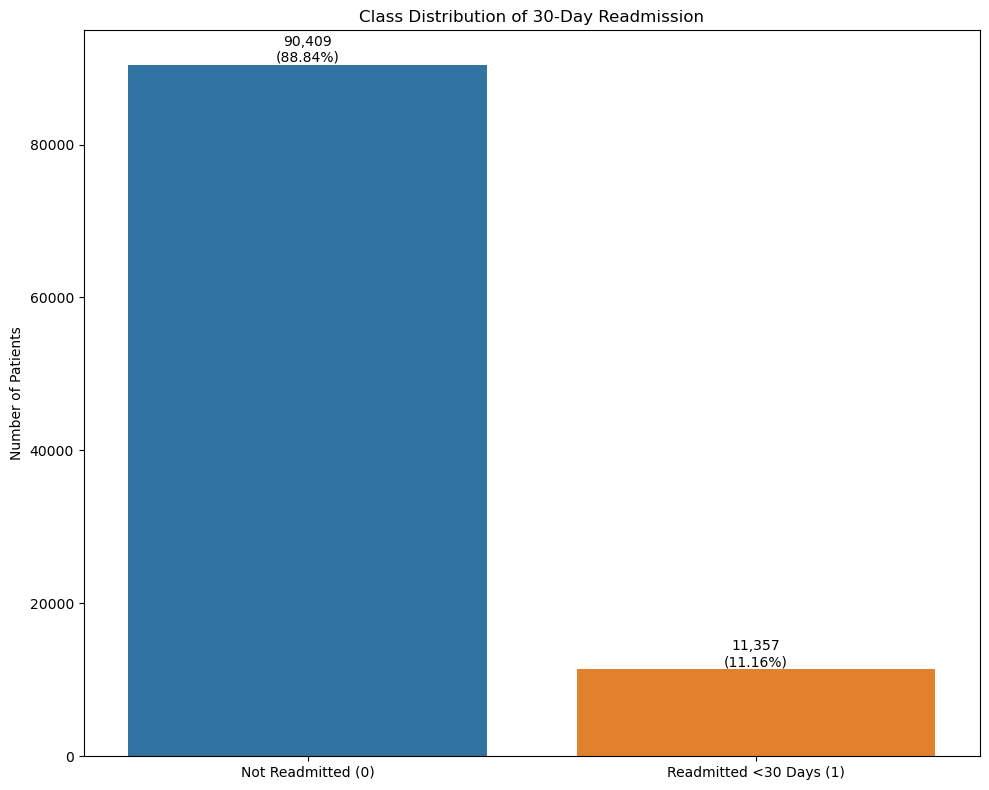

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (make sure CSV is local or downloaded)
df = pd.read_csv("diabetic_data.csv")

# Create binary label
df["label"] = df["readmitted"].apply(lambda x: 1 if x == "<30" else 0)

# Count values
counts = df["label"].value_counts().sort_index()

# Convert to readable labels
labels = ["Not Readmitted (0)", "Readmitted <30 Days (1)"]

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x=labels, y=counts.values)

# Add percentage labels
total = counts.sum()
for i, v in enumerate(counts.values):
    pct = (v / total) * 100
    plt.text(i, v, f"{v:,}\n({pct:.2f}%)", ha='center', va='bottom')

plt.title("Class Distribution of 30-Day Readmission")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

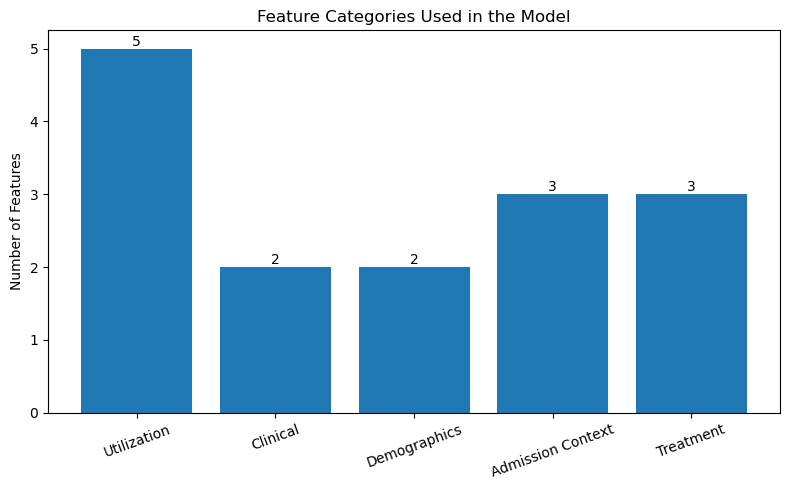

In [4]:
import matplotlib.pyplot as plt

# Define feature categories (based on your selected_cols)
feature_categories = {
    "Utilization": [
        "time_in_hospital",
        "num_medications",
        "number_inpatient",
        "number_emergency",
        "number_outpatient"
    ],
    "Clinical": [
        "A1Cresult",
        "max_glu_serum"
    ],
    "Demographics": [
        "age",
        "gender"
    ],
    "Admission Context": [
        "admission_type_id",
        "discharge_disposition_id",
        "admission_source_id"
    ],
    "Treatment": [
        "diabetesMed",
        "change",
        "insulin"
    ]
}

# Count number of features per category
categories = list(feature_categories.keys())
counts = [len(v) for v in feature_categories.values()]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(categories, counts)

# Add labels on bars
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha='center',
        va='bottom'
    )

plt.title("Feature Categories Used in the Model")
plt.ylabel("Number of Features")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

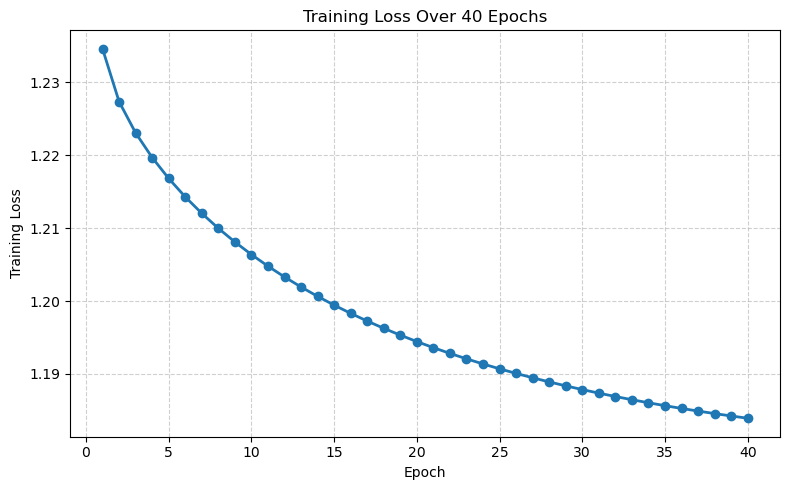

In [3]:
import matplotlib.pyplot as plt

epochs = list(range(1, 41))
losses = [
    1.234620, 1.227372, 1.223080, 1.219697, 1.216824,
    1.214299, 1.212038, 1.209988, 1.208113, 1.206388,
    1.204793, 1.203312, 1.201935, 1.200648, 1.199445,
    1.198318, 1.197259, 1.196263, 1.195326, 1.194443,
    1.193609, 1.192822, 1.192077, 1.191373, 1.190706,
    1.190074, 1.189475, 1.188907, 1.188367, 1.187855,
    1.187368, 1.186905, 1.186465, 1.186047, 1.185648,
    1.185269, 1.184907, 1.184563, 1.184235, 1.183922
]

plt.figure(figsize=(8, 5))
plt.plot(epochs, losses, marker='o', linewidth=2)
plt.title("Training Loss Over 40 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

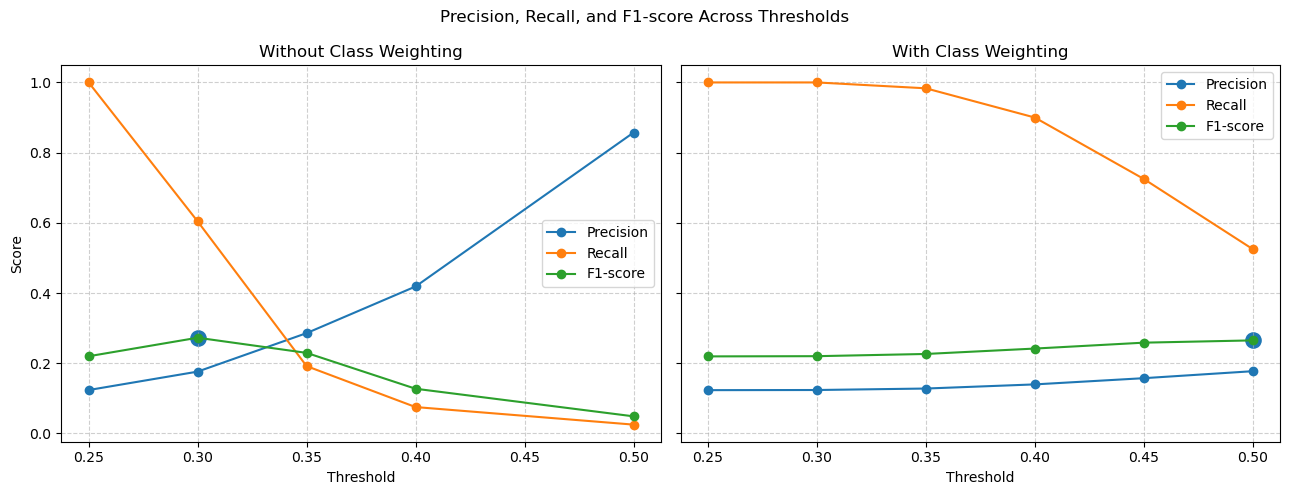

In [6]:
import matplotlib.pyplot as plt

# Thresholds
thresholds_no_weight = [0.25, 0.30, 0.35, 0.40, 0.50]
thresholds_weighted  = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

# Without class weighting
precision_no_weight = [0.1235, 0.1760, 0.2857, 0.4186, 0.8571]
recall_no_weight    = [1.0000, 0.6042, 0.1917, 0.0750, 0.0250]
f1_no_weight        = [0.2198, 0.2726, 0.2294, 0.1272, 0.0486]

# With class weighting
precision_weighted = [0.1232, 0.1236, 0.1278, 0.1396, 0.1573, 0.1772]
recall_weighted    = [1.0000, 1.0000, 0.9833, 0.9000, 0.7250, 0.5250]
f1_weighted        = [0.2194, 0.2200, 0.2263, 0.2417, 0.2585, 0.2650]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Left chart: without weighting
axes[0].plot(thresholds_no_weight, precision_no_weight, marker='o', label='Precision')
axes[0].plot(thresholds_no_weight, recall_no_weight, marker='o', label='Recall')
axes[0].plot(thresholds_no_weight, f1_no_weight, marker='o', label='F1-score')
axes[0].set_title("Without Class Weighting")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

# Highlight best F1 threshold
best_idx_no = f1_no_weight.index(max(f1_no_weight))
axes[0].scatter(
    thresholds_no_weight[best_idx_no],
    f1_no_weight[best_idx_no],
    s=120
)

# Right chart: with weighting
axes[1].plot(thresholds_weighted, precision_weighted, marker='o', label='Precision')
axes[1].plot(thresholds_weighted, recall_weighted, marker='o', label='Recall')
axes[1].plot(thresholds_weighted, f1_weighted, marker='o', label='F1-score')
axes[1].set_title("With Class Weighting")
axes[1].set_xlabel("Threshold")
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend()

# Highlight best F1 threshold
best_idx_w = f1_weighted.index(max(f1_weighted))
axes[1].scatter(
    thresholds_weighted[best_idx_w],
    f1_weighted[best_idx_w],
    s=120
)

plt.suptitle("Precision, Recall, and F1-score Across Thresholds")
plt.tight_layout()
plt.show()

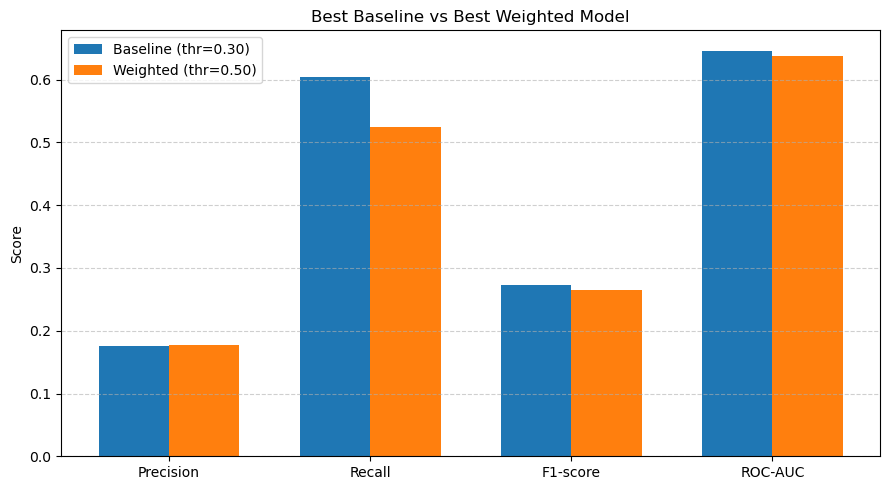

In [7]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Precision', 'Recall', 'F1-score', 'ROC-AUC']

baseline = [0.1760, 0.6042, 0.2726, 0.6463]   # threshold 0.30, no weighting
weighted = [0.1772, 0.5250, 0.2650, 0.6385]   # threshold 0.50, weighted

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, baseline, width, label='Baseline (thr=0.30)')
plt.bar(x + width/2, weighted, width, label='Weighted (thr=0.50)')

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Best Baseline vs Best Weighted Model")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

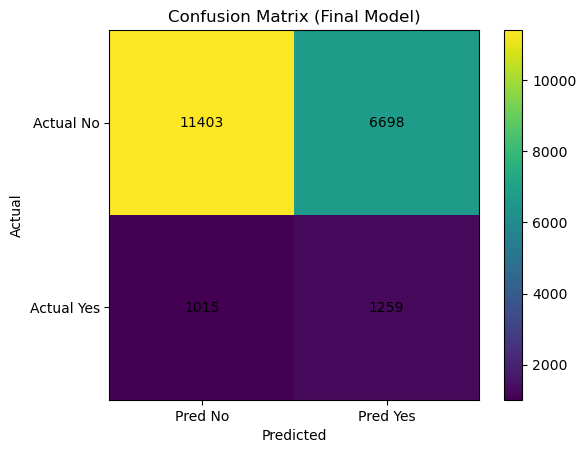

In [8]:
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([[11403, 6698],
               [1015, 1259]])

plt.figure()
plt.imshow(cm)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xticks([0,1], ['Pred No', 'Pred Yes'])
plt.yticks([0,1], ['Actual No', 'Actual Yes'])

plt.title("Confusion Matrix (Final Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()
plt.show()

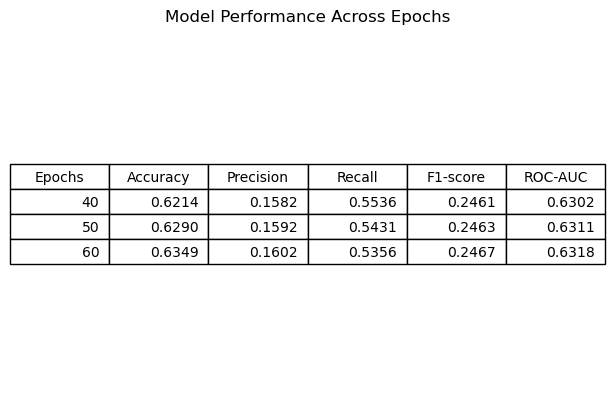

In [9]:
import matplotlib.pyplot as plt

# Data
columns = ["Epochs", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
data = [
    ["40", "0.6214", "0.1582", "0.5536", "0.2461", "0.6302"],
    ["50", "0.6290", "0.1592", "0.5431", "0.2463", "0.6311"],
    ["60", "0.6349", "0.1602", "0.5356", "0.2467", "0.6318"]
]

# Create figure
fig, ax = plt.subplots()
ax.axis('off')

# Create table
table = ax.table(cellText=data, colLabels=columns, loc='center')

# Adjust styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title("Model Performance Across Epochs")
plt.show()

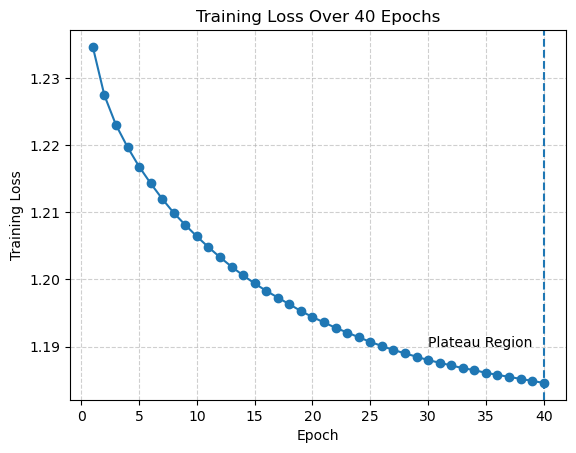

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, 41))

loss_values = [
1.2346,1.2274,1.2230,1.2197,1.2168,1.2143,1.2120,1.2099,1.2081,1.2064,
1.2048,1.2033,1.2019,1.2006,1.1994,1.1983,1.1973,1.1963,1.1953,1.1944,
1.1936,1.1928,1.1921,1.1914,1.1907,1.1901,1.1895,1.1890,1.1885,1.1880,
1.1876,1.1872,1.1868,1.1865,1.1861,1.1858,1.1855,1.1852,1.1849,1.1846
]

plt.figure()
plt.plot(epochs, loss_values, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over 40 Epochs")

plt.axvline(x=40, linestyle='--')
plt.text(30, 1.19, "Plateau Region")

plt.grid(True, linestyle="--", alpha=0.6)
plt.show()